https://www.youtube.com/watch?v=w8yWXqWQYmU&t=1282s
Samson Zhang

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c digit-recognizer

  0% 0.00/15.3M [00:00<?, ?B/s]
100% 15.3M/15.3M [00:00<00:00, 1.04GB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/digit-recognizer.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
data = pd.read_csv("/content/train.csv")
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# change to numpy arrays to have a better grip of it
data_n = np.array(data)
np.random.shuffle(data_n)
m, n = data_n.shape
# transpose
data_train = data_n[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [ ]:
def init_params():
  W1 = np.random.rand(10, 784) -0.5
  b1 = np.random.rand(10, 1) -0.5

  W2 = np.random.rand(10, 10) -0.5
  b2 = np.random.rand(10, 1) -0.5

  return W1, b1, W2, b2

In [ ]:
def Relu(Z, d=False):
  """
  0 if z < 0
  z if z >= 0
  """
  if d:
    return Z > 0
  else:
    return np.maximum(Z, 0)

In [ ]:
def one_hot(Y):
  one_hot_Y = np.zeros((Y.size, Y.max() + 1))
  one_hot_Y[np.arange(Y.size), Y] = 1
  return one_hot_Y.T

In [ ]:
def Softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

In [ ]:
def forward_prop(W1, b1, W2, b2, X):
  Z1 = W1.dot(X) + b1
  A1 = Relu(Z1)

  Z2 = W2.dot(A1) + b2
  A2 = Softmax(Z2)

  return Z1, A1, Z2, A2

In [ ]:
def back_prop(Z1, Z2, A1, A2, X, Y, W2):
  one_hot_y = one_hot(Y)
  dZ2 = A2 - one_hot_y
  dW2 = 1 / m * dZ2.dot(A1.T)
  db2 = 1 / m * np.sum(dZ2)
  dZ1 = W2.T.dot(dZ2) * Relu(Z1, d=True)
  dW1 = 1 / m * dZ1.dot(X.T)
  db1 = 1 / m * np.sum(dZ1)

  return dW1, db1, dW2, db2

In [ ]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
  W1 = W1 - alpha * dW1
  b1 = b1 - alpha * db1
  W2 = W2 - alpha * dW2
  b2 = b2 - alpha * db2

  return W1, b1, W2, b2

In [ ]:
def get_predictions(A2):
  return np.argmax(A2, 0)

In [ ]:
def get_accuracy(predictions, Y):
  print(predictions, Y)
  return np.sum(predictions == Y) / Y.size

In [ ]:
def gradient_descent(X, Y, alpha, epochs):
  W1, b1, W2, b2 = init_params()
  for i in range(epochs):
      Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
      dW1, db1, dW2, db2 = back_prop(Z1, Z2, A1, A2, X, Y, W2)
      W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
      if i % 10 == 0:
          print("Iteration: ", i)
          predictions = get_predictions(A2)
          print(get_accuracy(predictions, Y))
  return W1, b1, W2, b2

In [ ]:
eW1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 100)

Iteration:  0
[3 3 3 ... 3 3 3] [1 9 5 ... 1 7 2]
0.11519512195121952
Iteration:  10
[8 9 8 ... 1 9 9] [1 9 5 ... 1 7 2]
0.19378048780487805
Iteration:  20
[0 9 0 ... 1 9 9] [1 9 5 ... 1 7 2]
0.3074878048780488
Iteration:  30
[6 9 0 ... 1 9 0] [1 9 5 ... 1 7 2]
0.3641219512195122
Iteration:  40
[6 9 0 ... 1 9 0] [1 9 5 ... 1 7 2]
0.4107560975609756
Iteration:  50
[6 9 0 ... 1 9 8] [1 9 5 ... 1 7 2]
0.44921951219512196
Iteration:  60
[1 9 0 ... 1 9 8] [1 9 5 ... 1 7 2]
0.49258536585365853
Iteration:  70
[1 9 0 ... 1 9 8] [1 9 5 ... 1 7 2]
0.528829268292683
Iteration:  80
[1 9 0 ... 1 9 8] [1 9 5 ... 1 7 2]
0.5587804878048781
Iteration:  90
[1 9 0 ... 1 9 8] [1 9 5 ... 1 7 2]
0.5850975609756097


In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [1]
Label:  1


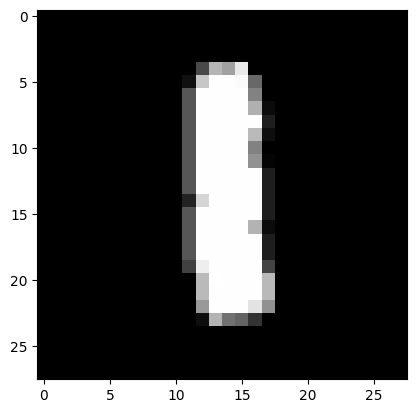

Prediction:  [9]
Label:  9


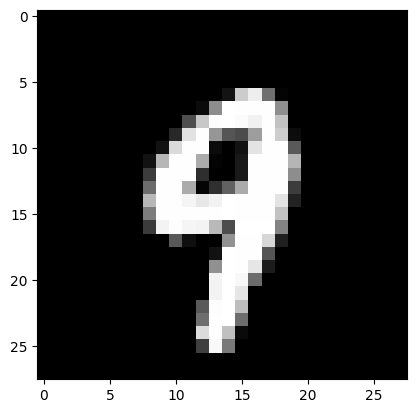

Prediction:  [5]
Label:  5


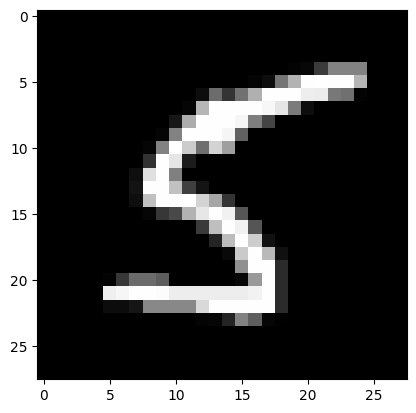

Prediction:  [8]
Label:  8


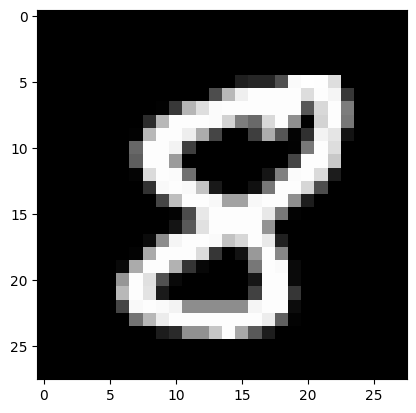

In [ ]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)